In [1]:
import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

In [2]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, transform=transform, download=True)

test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 125MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 28.2MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 135MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.74MB/s]


In [3]:
class CNNFeatureExtractor(nn.Module):
    def __init__(self):
        super(CNNFeatureExtractor, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),  # 1 channel input
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # Flatten
        return x

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNNFeatureExtractor().to(device)
model.eval()

CNNFeatureExtractor(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
)

In [5]:
def extract_features(loader, model):
    features = []
    labels = []

    with torch.no_grad():
        for images, lbls in loader:
            images = images.to(device)
            output = model(images)
            features.append(output.cpu().numpy())
            labels.extend(lbls.numpy())

    return np.vstack(features), np.array(labels)

train_features, train_labels = extract_features(train_loader, model)
test_features, test_labels = extract_features(test_loader, model)

In [6]:
def retrieve(query_feature, database_features, k=5):
    similarities = cosine_similarity(query_feature.reshape(1, -1), database_features)
    indices = np.argsort(similarities[0])[::-1][:k]
    return indices

In [7]:
def show_results(query_idx, k=5):
    query_feature = test_features[query_idx]
    indices = retrieve(query_feature, train_features, k)

    plt.figure(figsize=(10, 3))

    # Query
    plt.subplot(1, k+1, 1)
    plt.imshow(test_dataset[query_idx][0].squeeze(), cmap='gray')
    plt.title("Query")
    plt.axis('off')

    # Retrieved
    for i, idx in enumerate(indices):
        plt.subplot(1, k+1, i+2)
        plt.imshow(train_dataset[idx][0].squeeze(), cmap='gray')
        plt.axis('off')

    plt.show()

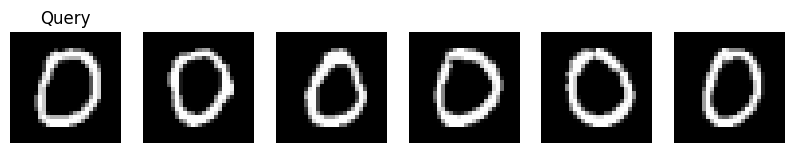

In [8]:
show_results(query_idx=10, k=5)

In [9]:
def evaluate(test_features, test_labels, train_features, train_labels, k=5):
    precision_list = []
    recall_list = []

    for i in range(len(test_features)):
        query = test_features[i]
        true_label = test_labels[i]

        indices = retrieve(query, train_features, k)
        retrieved_labels = train_labels[indices]

        relevant = np.sum(retrieved_labels == true_label)

        precision = relevant / k
        recall = relevant / np.sum(train_labels == true_label)

        precision_list.append(precision)
        recall_list.append(recall)

    return np.mean(precision_list), np.mean(recall_list)

In [10]:
precision, recall = evaluate(
    test_features, test_labels,
    train_features, train_labels,
    k=5
)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.8233400000000002
Recall: 0.0006836196878673006


In [11]:
def compute_map(test_features, test_labels, train_features, train_labels, k=5):
    APs = []

    for i in range(len(test_features)):
        query = test_features[i]
        true_label = test_labels[i]

        indices = retrieve(query, train_features, k)
        retrieved_labels = train_labels[indices]

        correct = 0
        precision_sum = 0

        for j in range(k):
            if retrieved_labels[j] == true_label:
                correct += 1
                precision_sum += correct / (j+1)

        AP = precision_sum / max(correct, 1)
        APs.append(AP)

    return np.mean(APs)

mAP = compute_map(test_features, test_labels, train_features, train_labels)
print("mAP:", mAP)

mAP: 0.88313
